# Solar Generation in AIB Countries

This notebook quantifies solar power generation across AIB (Association of Issuing Bodies) member countries using ENTSO-E actual generation data, and compares it to Guarantee of Origin (GO) issuance volumes.

In [51]:
aib_members = [
    'AL', 'AT', 'BE', 'BA', 'BG', 'HR', 'CY', 'CZ', 'DK', 'EE',
    'FI', 'FR', 'GE', 'DE', 'GR', 'HU', 'IS', 'IE', 'IT', 'XK', 
    'LV', 'LT', 'LU', 'ME', 'NL', 'MK', 'NO', 'PT', 'RO', 'RS', 
    'SK', 'SI', 'ES', 'SE', 'CH', 'UA'
]

aib_electricity_scheme_group = [
    'AT', 'BE', 'HR', 'CY', 'CZ', 'DK', 'EE', 'FI', 'FR', 'DE', 
    'GR', 'HU', 'IS', 'IE', 'IT', 'LV', 'LT', 'LU', 'NL', 'NO', 
    'PT', 'RS', 'SK', 'SI', 'ES', 'SE', 'CH'
]

country_to_grid = {'AT': 'APG', 'BE': 'ELIA', 'FR': 'RTE', 'GB': 'NGRID', 'NL': 'TENNET'}
grid_to_country = {v: k for k, v in country_to_grid.items()}

## Data Collection

We query the ENTSO-E solar production curves from the database. Each curve represents actual solar generation (MW) for a specific country/zone. The data is resampled to hourly granularity where needed, deduplicated by keeping the latest forecast revision, and aggregated per country. Unlike wind, solar generation has no onshore/offshore distinction, but some countries (IT, DK) report by bidding zone which must be summed to get a national total.

In [ ]:
from kad_functions.sql_data import get_sql_query

solar_query = """
SELECT CurveId, CurveName, CountryCode
FROM pub.dimMetadata
WHERE (CurveName LIKE '%entsoe-power-production%solar%'
    OR CurveName LIKE '%EntsoE-ActualGeneration%solar%'
    OR CurveName LIKE '%EntsoE_Actual_Generation%solar%'
    OR CurveName LIKE '%EntsoE_ActualGeneration%solar%')
    AND Curvename NOT LIKE '%raw'
ORDER BY CountryCode
"""

solar_countries = get_sql_query(solar_query)
solar_countries = solar_countries.sort_values(by='CountryCode').reset_index(drop=True)

# Fix country code assignments where CurveName contains grid operator names
solar_countries.loc[solar_countries['CurveName'].str.contains('-APG-', case=False, na=False), 'CountryCode'] = 'AT'
solar_countries.loc[solar_countries['CurveName'].str.contains('-NO', case=False, na=False), 'CountryCode'] = 'NO'
solar_countries.loc[solar_countries['CurveName'].str.contains('-IT-NORTH', case=False, na=False), 'CountryCode'] = 'IT'

solar_countries = solar_countries[solar_countries['CountryCode'].isin(aib_electricity_scheme_group)]
solar_countries = solar_countries.sort_values(by='CountryCode').reset_index(drop=True)

display(solar_countries)

,CurveId,CurveName,CountryCode
0,910000132,EntsoE_ActualGeneration_AT_Solar_PROD,AT
1,910000133,EntsoE_ActualGeneration_AT_Solar_CONS,AT
2,1000318267,ENTSOE-POWER-PRODUCTION-ACTUAL-APG-SOLAR-MW,AT
3,1000318269,ENTSOE-POWER-PRODUCTION-ACTUAL-ELIA-SOLAR-MW,BE
4,1500029396,ENTSOE-POWER-PRODUCTION-ACTUAL-BE-SOLAR-MW,BE
5,910000146,EntsoE-ActualGeneration-BE-Solar,BE
7,910000230,EntsoE-ActualGeneration-CH-Solar,CH
8,910003004,ENTSOE_ActualGeneration_CZ_SOLAR__PROD,CZ
9,1000318266,ENTSOE-POWER-PRODUCTION-ACTUAL-DE-SOLAR-MW,DE
10,910002144,EntsoE-ActualGeneration-DE-TBW-Solar-C,DE


In [53]:
# Country filters - selected curve IDs to avoid double-counting
# Strategy: use one consistent source per country, prefer ACTUAL/national-level curves,
# only PROD (not CONS), sum regional curves for IT/DK/NO
filtered_curve_ids = [
    '1000318267',                # AT (APG national)
    '1000318269',                # BE (ELIA national)
    '910000230',                 # CH
    '910003004',                 # CZ PROD
    '1000318266',                # DE (national, not individual TSOs)
    '1000318272', '1000318273',  # DK1, DK2
    '1500028968',                # EE
    '910000222',                 # ES
    '1500019425',                # FI
    '1000318270',                # FR (RTE national)
    '910003086',                 # GR PROD
    '910004529',                 # HR PROD
    '1500027642',                # HU PROD
    # IT regions - PROD only
    '910000286',                 # IT NORTH
    '910000261',                 # IT CNOR
    '910000272',                 # IT CSOUTH
    '910000328',                 # IT SOUTH
    '910000321',                 # IT SICILY
    '910000311',                 # IT SARDINIA
    '1500023508',                # IT Calabria
    '1500029107',                # LT
    '1500029079',                # LV
    '910000189',                 # NL (national, not TenneT which excludes non-TenneT gen)
    # NO bidding zones
    '1500026493',                # NO1
    '1500026535',                # NO2
    '1500026577',                # NO3
    '1500026619',                # NO4
    '1500026661',                # NO5
    '910000343',                 # PT
    '1500029521',                # SE (national aggregate)
    '910003060',                 # SI PROD
    '910003019',                 # SK PROD
]

# Filter solar_countries to only selected curves
solar_countries = solar_countries[solar_countries['CurveId'].astype(str).isin(filtered_curve_ids)].reset_index(drop=True)
print(f"Filtered to {len(solar_countries)} curves across {solar_countries['CountryCode'].nunique()} countries")
display(solar_countries)

Filtered to 33 curves across 22 countries


,CurveId,CurveName,CountryCode
0,1000318267,ENTSOE-POWER-PRODUCTION-ACTUAL-APG-SOLAR-MW,AT
1,1000318269,ENTSOE-POWER-PRODUCTION-ACTUAL-ELIA-SOLAR-MW,BE
2,910000230,EntsoE-ActualGeneration-CH-Solar,CH
3,910003004,ENTSOE_ActualGeneration_CZ_SOLAR__PROD,CZ
4,1000318266,ENTSOE-POWER-PRODUCTION-ACTUAL-DE-SOLAR-MW,DE
5,1000318272,ENTSOE-POWER-PRODUCTION-ACTUAL-DK1-SOLAR-MW,DK
6,1000318273,ENTSOE-POWER-PRODUCTION-ACTUAL-DK2-SOLAR-MW,DK
7,1500028968,ENTSOE_ACTUAL_GENERATION_SOLAR_MW_QUARTERLY_EE,EE
8,910000222,EntsoE-ActualGeneration-ES-Solar,ES
9,1500019425,ENTSOE_ACTUAL_GENERATION_SOLAR_MW_HOURLY_FI,FI


In [54]:
available_solar_countries = sorted(set(solar_countries['CountryCode']))

print("Countries with solar generation data:", available_solar_countries)
print("Number of countries with solar generation data:", len(available_solar_countries))
print("Countries without solar generation data:", sorted(set(aib_electricity_scheme_group) - set(available_solar_countries)))

Countries with solar generation data: ['AT', 'BE', 'CH', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'HU', 'IT', 'LT', 'LV', 'NL', 'NO', 'PT', 'SE', 'SI', 'SK']
Number of countries with solar generation data: 22
Countries without solar generation data: ['CY', 'IE', 'IS', 'LU', 'RS']


In [55]:
import pandas as pd
import matplotlib.pyplot as plt

def resample_generation_data(df, granularity='h'):
    df = df.resample('15min').ffill()
    df = df.resample(granularity).mean()
    return df

def get_curve_data(curve_id, granularity='h'):
    country_query = f"""
        SELECT ValueDateUTC, ForecastDateUTC, Value
        FROM pub.Timeseries1_v02
        WHERE CurveId = {curve_id}
        AND ValueDateUTC >= '2020-01-01'
    """

    data = get_sql_query(country_query)
    data = data.sort_values('ForecastDateUTC').drop_duplicates(subset='ValueDateUTC', keep='last')
    data['ValueDateUTC'] = pd.to_datetime(data['ValueDateUTC'])
    data = data.set_index('ValueDateUTC').sort_index()
    data = data.drop(columns=['ForecastDateUTC'])

    resampled = resample_generation_data(data['Value'], granularity=granularity)
    return resampled

solar_generation = {}

for country_code in available_solar_countries:
    curve_ids = solar_countries[solar_countries['CountryCode'] == country_code]['CurveId'].values

    if len(curve_ids) > 0:
        country_data = {}
        for curve_id in curve_ids:
            print(f"Fetching solar curve {curve_id} for {country_code}")
            country_data[curve_id] = get_curve_data(curve_id)
        solar_generation[country_code] = pd.DataFrame(country_data).sum(axis=1)

# Build DataFrame with countries as columns, hourly datetime as index
df_solar = pd.DataFrame(solar_generation)
df_solar = df_solar.dropna(axis=1, how='all')

print(f"\nSolar generation data: {df_solar.shape[1]} countries")
display(df_solar)

Fetching solar curve 1000318267 for AT
Fetching solar curve 1000318269 for BE
Fetching solar curve 910000230 for CH
Fetching solar curve 910003004 for CZ
Fetching solar curve 1000318266 for DE
Fetching solar curve 1000318272 for DK
Fetching solar curve 1000318273 for DK
Fetching solar curve 1500028968 for EE
Fetching solar curve 910000222 for ES
Fetching solar curve 1500019425 for FI
Fetching solar curve 1000318270 for FR
Fetching solar curve 910003086 for GR
Fetching solar curve 910004529 for HR
Fetching solar curve 1500027642 for HU
Fetching solar curve 910000286 for IT
Fetching solar curve 910000328 for IT
Fetching solar curve 910000321 for IT
Fetching solar curve 910000311 for IT
Fetching solar curve 910000272 for IT
Fetching solar curve 1500023508 for IT
Fetching solar curve 910000261 for IT
Fetching solar curve 1500029107 for LT
Fetching solar curve 1500029079 for LV
Fetching solar curve 910000189 for NL
Fetching solar curve 1500026661 for NO
Fetching solar curve 1500026619 for N

,AT,BE,CH,CZ,DE,DK,EE,ES,FI,FR,...,HU,IT,LT,LV,NL,NO,PT,SE,SI,SK
ValueDateUTC,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,0.0,0.00000,0.000000,0.0000,0.00000,0.000000,0.100,15.0,7.0000,0.00,...,0.00000,0.000000,0.000000,NaN,0.0000,NaN,0.0,NaN,0.000000,1.00
2020-01-01 01:00:00,0.0,0.00000,0.000000,0.0000,0.00000,0.000000,0.100,15.0,7.0000,0.00,...,0.00000,1.000000,0.000000,NaN,0.0000,NaN,0.0,NaN,0.000000,1.00
2020-01-01 02:00:00,0.0,0.00000,0.000000,0.0000,0.00000,0.000000,0.100,15.0,7.0000,0.00,...,0.00000,0.000000,0.000000,NaN,0.0000,NaN,0.0,NaN,0.000000,1.00
2020-01-01 03:00:00,0.0,0.00000,0.000000,0.0000,0.00000,0.000000,0.100,16.0,7.0000,0.00,...,0.00000,0.000000,0.000000,NaN,0.0000,NaN,0.0,NaN,0.000000,1.00
2020-01-01 04:00:00,0.0,0.00000,0.000000,0.0000,0.00000,0.000000,0.100,26.0,7.0000,0.00,...,0.00000,0.000000,0.000000,NaN,0.0000,NaN,0.0,NaN,0.000000,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-27 03:00:00,23.0,2.51425,5.737730,96.0875,556.88450,107.407100,151.275,NaN,180.7775,0.00,...,154.23050,65.250000,266.342568,248.0,2.3975,0.0,0.0,105.30050,10.226342,7.25
2026-05-27 04:00:00,283.0,351.45525,254.211502,358.9575,4416.15425,365.076733,253.725,NaN,318.0550,459.78,...,758.62875,1008.250000,561.105553,503.0,17.7100,0.0,0.0,331.16200,131.957838,41.10
2026-05-27 05:00:00,1159.0,1222.70675,868.651794,932.2025,9904.50150,NaN,340.600,NaN,504.7900,2271.55,...,1859.23000,4345.500000,860.537593,726.0,50.7245,0.063856,58.2,710.07225,269.791687,117.65


## Solar Generation Overview

The following plot shows monthly average solar generation across the available AIB member countries. Solar generation exhibits strong seasonal patterns with peaks in summer months and troughs in winter, driven by irradiance levels and daylight hours.

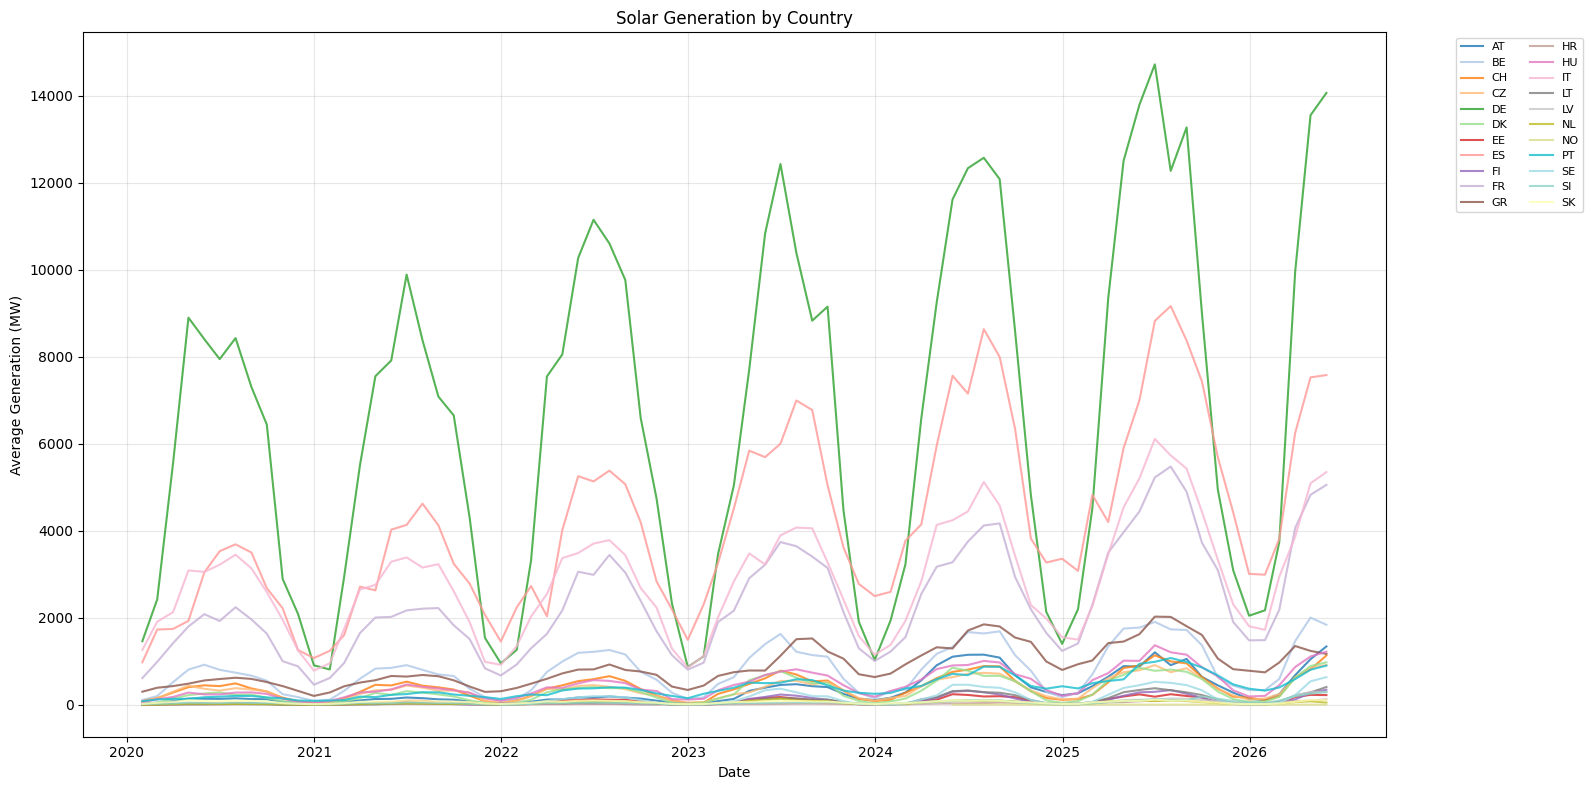

In [56]:
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

# Assign consistent colors to all countries
all_countries = sorted(df_solar.columns)
_colors = (plt.cm.tab20.colors[:20] + plt.cm.Set3.colors[:7])
country_colors = {country: _colors[i % len(_colors)] for i, country in enumerate(all_countries)}

# Monthly average solar generation
monthly_solar = df_solar.resample('ME').mean()
for country in sorted(monthly_solar.columns):
    ax.plot(monthly_solar.index, monthly_solar[country], label=country, alpha=0.8, color=country_colors[country])
ax.set_xlabel('Date')
ax.set_ylabel('Average Generation (MW)')
ax.set_title('Solar Generation by Country')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparison with GO Issuances

We compare ENTSO-E actual solar generation (converted to MWh) with GO issuance data from AIB statistics. The GO data is filtered for electricity certificates with solar as the energy source. Monthly generation is matched to monthly GO issuance by country.

In [57]:
import pandas as pd

path_1 = "/Users/kad/Library/CloudStorage/OneDrive-InCommoditiesAS/Data/GOs/GO_All_Statistics_1.csv"
df_1 = pd.read_csv(path_1, sep=",")

path_2 = "/Users/kad/Library/CloudStorage/OneDrive-InCommoditiesAS/Data/GOs/GO_All_Statistics_2.csv"
df_2 = pd.read_csv(path_2, sep=",")

df = pd.concat([df_1, df_2], ignore_index=True)

display(df)

,year_month_date,year,month_name,domain_name,energy_carrier,energy_source_name,energy_source_level1,energy_source_level2,production_technology_name,production_date_cancel,production_date_expire,production_date_issue,transaction_date_cancel,transaction_date_expire,transaction_date_export,transaction_date_import,transaction_date_issue,transaction_date_transfer,transaction_date_withdraw
0,2025-03-01,2025,March,PT - Portugal,EECS-Electricity,F01010101,Renewable,Renewable - Biomass,T050202,0,0,0,0,0,0,1134,0,0,0
1,2026-03-01,2026,March,CZ - Czech Republic,EECS-Electricity,F01030400,Renewable,Renewable - Biomass,T050500,0,0,0,1918,0,0,1918,0,0,0
2,2025-05-01,2025,May,FR - France,EECS-Electricity,F01010301,Renewable,Renewable - Biomass,T050301,5529,0,0,0,0,0,0,0,0,0
3,2023-03-01,2023,March,CZ - Czech Republic,EECS-Electricity,F01050100,Renewable,Renewable - Wind,T020000,59613,447,44798,92322,2238,27707,41757,44047,47886,0
4,2024-03-01,2024,March,FR - France,EECS-Electricity,F01030400,Renewable,Renewable - Biomass,T050502,0,0,0,2000,0,0,2000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114135,2022-12-01,2022,December,IT - Italy,EECS-Electricity,F01010101,Renewable,Renewable - Biomass,T050000,147307,0,128702,0,0,7254,263060,154040,10722,0
114136,2019-05-01,2019,May,NO - Norway,EECS-Electricity,F01050200,Renewable,Renewable - Hydro & Marine,T030000,2309808,40178,8019101,356688,817501,3432797,415589,7062114,984905,0
114137,2020-04-01,2020,April,AT - Austria,EECS-Electricity,F01030300,Renewable,Renewable - Biomass,T050501,0,0,0,357,0,0,0,0,0,0
114138,2022-02-01,2022,February,AT - Austria,EECS-Electricity,F01010300,Renewable,Renewable - Biomass,T050202,0,0,0,0,0,0,0,0,14626,0


In [58]:
go_df = df.copy()

# Only consider energy carrier electricity for now
go_df = go_df[go_df['energy_carrier'].str.contains('Electricity')]

# Calendar columns
go_df["month"] = go_df["year_month_date"].str.split("-").str[1].astype(int)
go_df["year"] = go_df["year"].astype(int)

go_df = go_df.drop(columns=["year_month_date", "month_name"])

# Classification columns
go_df['country_code'] = go_df['domain_name'].str.split(' ').str[0].astype(str)
go_df['energy_source_category'] = go_df['energy_source_level1'].astype(str)
go_df['energy_source'] = go_df['energy_source_level2'].str.split(' ').str[-1].astype(str)

go_df = go_df.drop(columns=['domain_name', 'energy_carrier', 'energy_source_name', 'energy_source_level1', 'energy_source_level2', 'production_technology_name'])

# Columns reordering
go_df = go_df[['year', 'month', 'country_code', 'energy_source_category', 'energy_source'] + go_df.columns[1:11].tolist()]

# Remove incomplete last month data
go_df = go_df[(go_df['year'] >= 2020) & ~((go_df['year'] == 2026) & (go_df['month'] == 4))]

display(go_df)

,year,month,country_code,energy_source_category,energy_source,production_date_cancel,production_date_expire,production_date_issue,transaction_date_cancel,transaction_date_expire,transaction_date_export,transaction_date_import,transaction_date_issue,transaction_date_transfer,transaction_date_withdraw
0,2025,3,PT,Renewable,Biomass,0,0,0,0,0,0,1134,0,0,0
1,2026,3,CZ,Renewable,Biomass,0,0,0,1918,0,0,1918,0,0,0
2,2025,5,FR,Renewable,Biomass,5529,0,0,0,0,0,0,0,0,0
3,2023,3,CZ,Renewable,Wind,59613,447,44798,92322,2238,27707,41757,44047,47886,0
4,2024,3,FR,Renewable,Biomass,0,0,0,2000,0,0,2000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114133,2021,11,DK,Renewable,Marine,46596,0,190,0,4673,1024,11840,233,0,0
114135,2022,12,IT,Renewable,Biomass,147307,0,128702,0,0,7254,263060,154040,10722,0
114137,2020,4,AT,Renewable,Biomass,0,0,0,357,0,0,0,0,0,0
114138,2022,2,AT,Renewable,Biomass,0,0,0,0,0,0,0,0,14626,0


In [61]:
# Filter GO data for solar only
solar_go = go_df[go_df['energy_source'] == 'Solar'].copy()

# Monthly GO issuance (MWh) by country
go_issued = solar_go.groupby(['year', 'month', 'country_code'])['production_date_issue'].sum().reset_index()
go_issued.columns = ['year', 'month', 'country_code', 'go_issued_mwh']
go_issued['date'] = pd.to_datetime(go_issued[['year', 'month']].assign(day=1))

# Monthly ENTSO-E generation (MW hourly -> MWh by summing hourly values)
monthly_gen_mwh = df_solar.resample('ME').sum()  # sum of hourly MW = MWh

# Reshape to long format for comparison
gen_long = monthly_gen_mwh.reset_index().melt(id_vars='ValueDateUTC', var_name='country_code', value_name='entsoe_mwh')
gen_long['year'] = gen_long['ValueDateUTC'].dt.year
gen_long['month'] = gen_long['ValueDateUTC'].dt.month

# Merge GO issuance with ENTSO-E generation
comparison = gen_long.merge(go_issued, on=['year', 'month', 'country_code'], how='outer')
comparison['date'] = pd.to_datetime(comparison[['year', 'month']].assign(day=1))
comparison = comparison.sort_values(['country_code', 'date'])

# GO issuance rate (% of generation that got GOs issued)
entsoe_safe = comparison['entsoe_mwh'].where(comparison['entsoe_mwh'] != 0)
comparison['go_rate'] = comparison['go_issued_mwh'] / entsoe_safe * 100

display(comparison[['date', 'country_code', 'entsoe_mwh', 'go_issued_mwh', 'go_rate']].dropna(subset=['entsoe_mwh', 'go_issued_mwh']))

,date,country_code,entsoe_mwh,go_issued_mwh,go_rate
0,2020-01-01,AT,19033.0,55671.0,292.497242
27,2020-02-01,AT,33513.0,63676.0,190.003879
55,2020-03-01,AT,60004.0,87981.0,146.625225
83,2020-04-01,AT,101515.0,121158.0,119.34985
111,2020-05-01,AT,102552.0,122324.0,119.279975
...,...,...,...,...,...
2097,2025-11-01,SK,17750.7,1538.0,8.664447
2127,2025-12-01,SK,10579.0,900.0,8.50742
2157,2026-01-01,SK,11582.0,891.0,7.692972
2186,2026-02-01,SK,19221.2,2047.0,10.649699


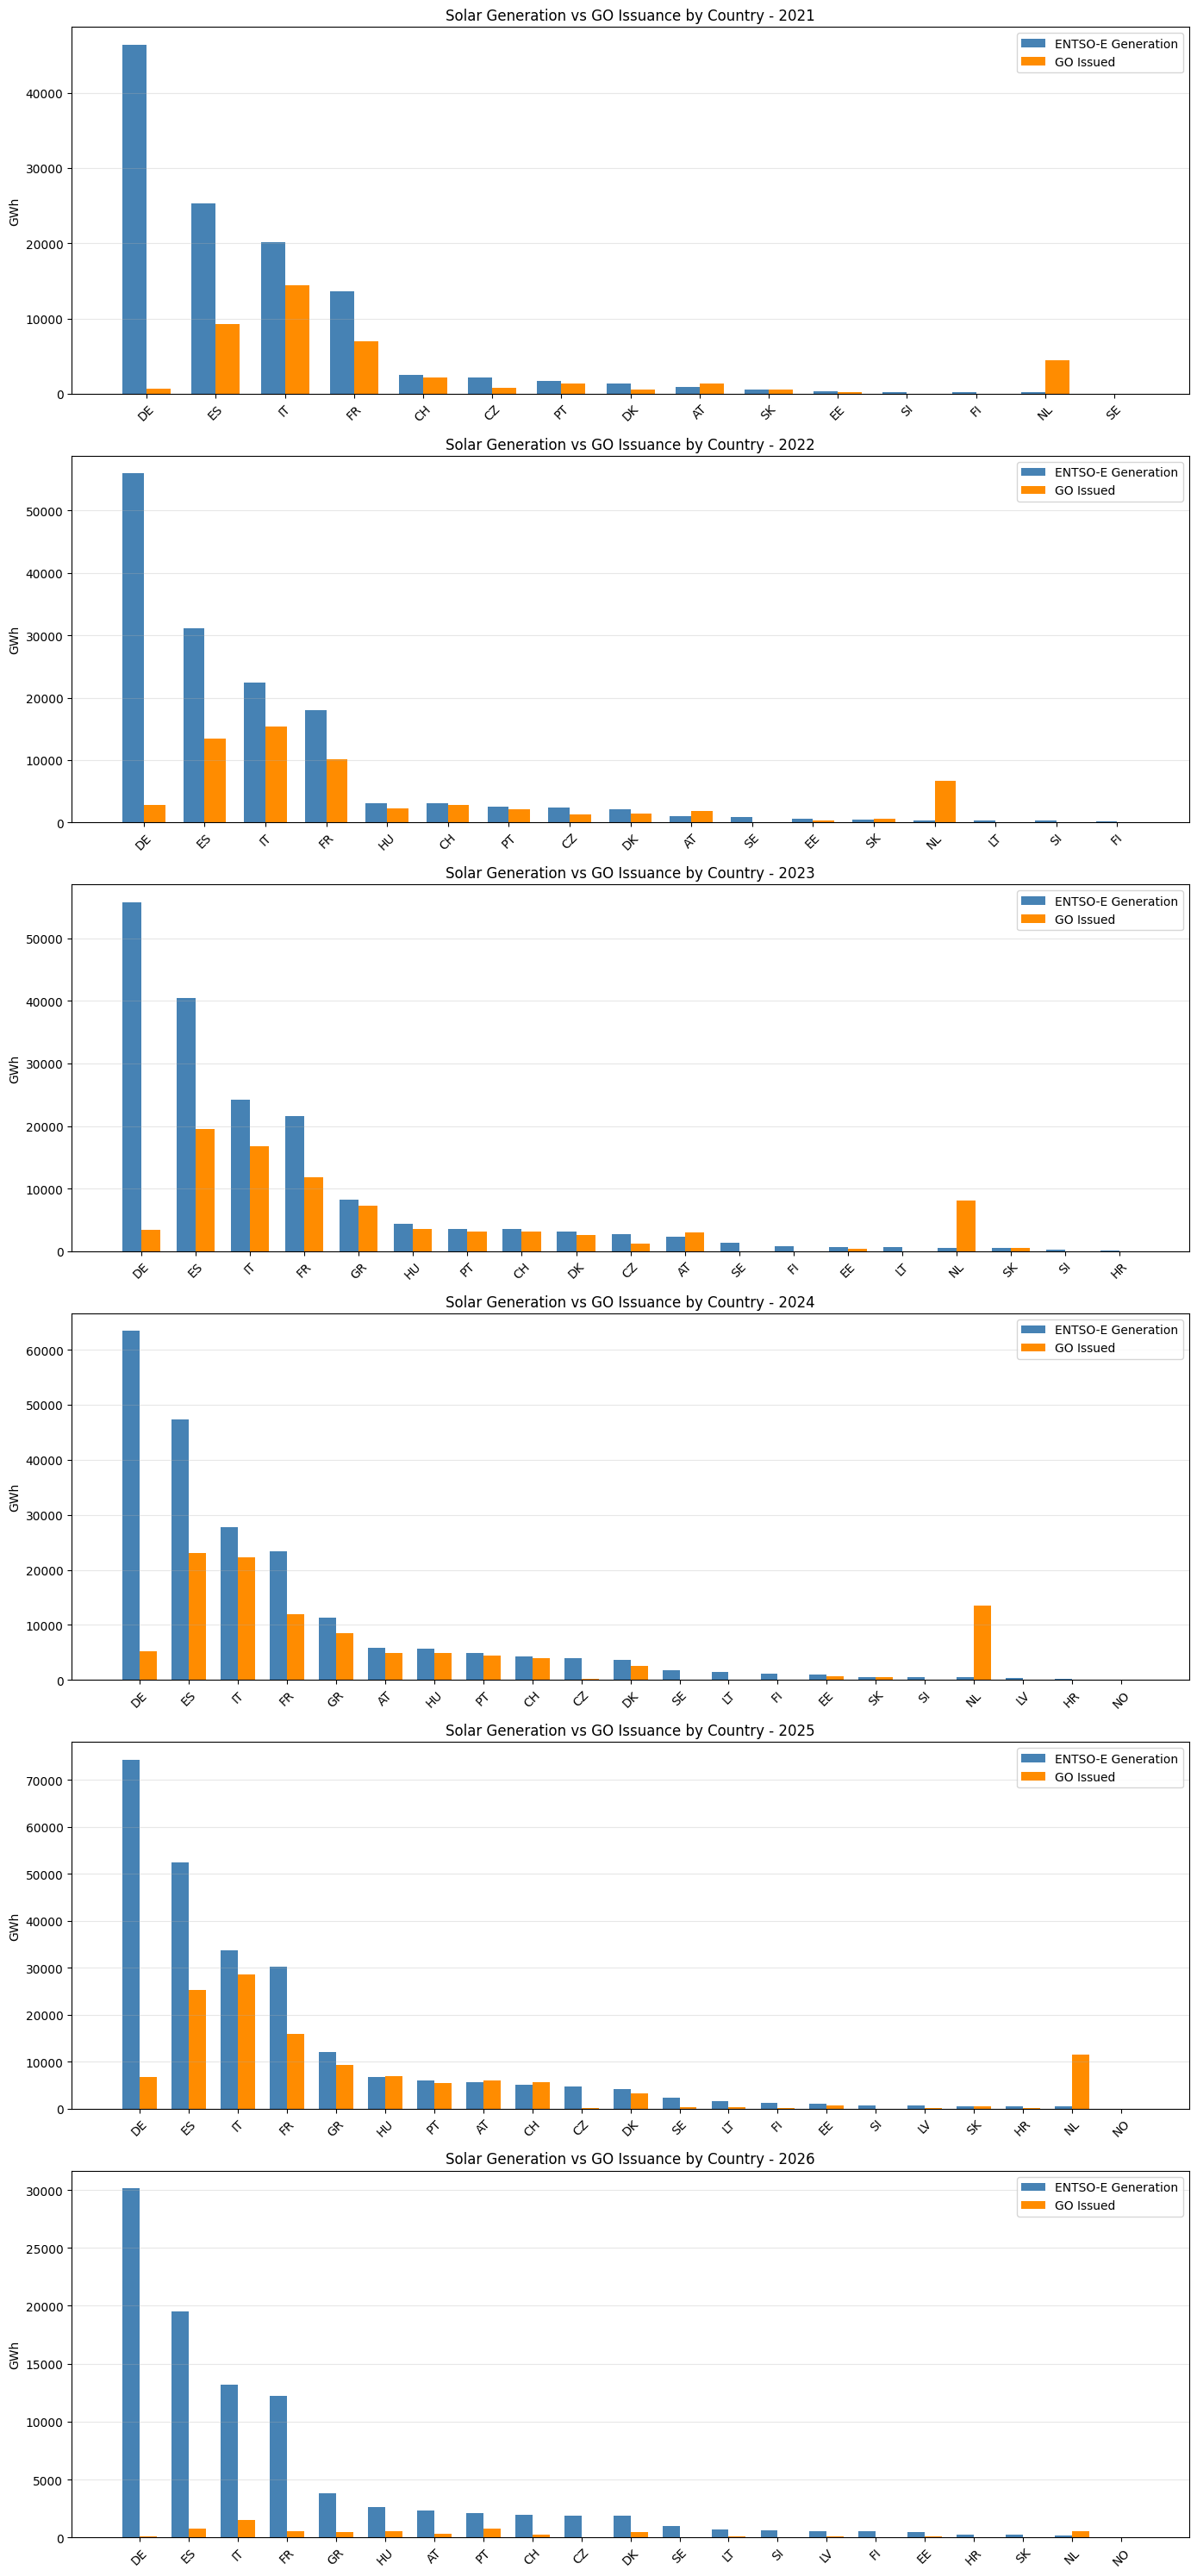

In [62]:
# Plot comparison: annual totals by country
annual = comparison.groupby(['country_code', comparison['date'].dt.year]).agg(
    entsoe_gwh=('entsoe_mwh', lambda x: x.sum() / 1e3),
    go_issued_gwh=('go_issued_mwh', lambda x: x.sum() / 1e3)
).reset_index()
annual.columns = ['country_code', 'year', 'entsoe_gwh', 'go_issued_gwh']

# Filter to countries present in both datasets and year 2021+
annual = annual[(annual['entsoe_gwh'] > 0) & (annual['go_issued_gwh'] > 0) & (annual['year'] >= 2021)]

# Plot per year
years = sorted(annual['year'].unique())
fig, axes = plt.subplots(len(years), 1, figsize=(14, 5 * len(years)))

for i, year in enumerate(years):
    ax = axes[i] if len(years) > 1 else axes
    year_data = annual[annual['year'] == year].sort_values('entsoe_gwh', ascending=False)
    
    x = range(len(year_data))
    width = 0.35
    ax.bar([p - width/2 for p in x], year_data['entsoe_gwh'], width, label='ENTSO-E Generation', color='steelblue')
    ax.bar([p + width/2 for p in x], year_data['go_issued_gwh'], width, label='GO Issued', color='darkorange')
    ax.set_xticks(list(x))
    ax.set_xticklabels(year_data['country_code'], rotation=45)
    ax.set_ylabel('GWh')
    ax.set_title(f'Solar Generation vs GO Issuance by Country - {year}')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## GO Issuance Factors & 2026 Estimation

Calculate the average ratio of GO issuance to ENTSO-E generation per country (2021–2025), then apply these factors to 2026 generation to estimate expected GO volumes not yet issued.

In [63]:
# Calculate GO factor per country based on 2021-2025 annual totals
historical = annual[(annual['year'] >= 2021) & (annual['year'] <= 2025)].copy()
historical['go_factor'] = historical['go_issued_gwh'] / historical['entsoe_gwh']

# Average factor per country across all available years
go_factors = historical.groupby('country_code').agg(
    avg_factor=('go_factor', 'mean'),
    min_factor=('go_factor', 'min'),
    max_factor=('go_factor', 'max'),
    years_count=('year', 'count'),
    avg_gen_gwh=('entsoe_gwh', 'mean')
).sort_values('avg_gen_gwh', ascending=False).round(3)

print("GO Issuance Factor by Country (2021-2025)")
print("Factor = GO Issued / ENTSO-E Generation")
print("=" * 65)
display(go_factors)

# 2026 data: generation and already-issued GOs
gen_2026 = annual[annual['year'] == 2026][['country_code', 'entsoe_gwh', 'go_issued_gwh']].copy()
gen_2026 = gen_2026.merge(go_factors[['avg_factor']].reset_index(), on='country_code', how='left')

# Estimate expected total 2026 GOs and the not-yet-issued portion
gen_2026['expected_go_gwh'] = gen_2026['entsoe_gwh'] * gen_2026['avg_factor']
gen_2026['not_yet_issued_gwh'] = gen_2026['expected_go_gwh'] - gen_2026['go_issued_gwh']
gen_2026['pct_issued'] = (gen_2026['go_issued_gwh'] / gen_2026['expected_go_gwh'] * 100).round(1)
gen_2026 = gen_2026.sort_values('expected_go_gwh', ascending=False).round(1)

print("\n\n2026 Estimated Solar GO Issuance vs Already Issued (GWh)")
print("Based on generation to date and historical GO factors")
print("=" * 75)
display(gen_2026[['country_code', 'entsoe_gwh', 'avg_factor', 'expected_go_gwh', 'go_issued_gwh', 'not_yet_issued_gwh', 'pct_issued']])

total_expected = gen_2026['expected_go_gwh'].sum()
total_issued = gen_2026['go_issued_gwh'].sum()
print(f"\nTotal across all countries:")
print(f"  Expected 2026 GOs (based on gen to date): {total_expected:,.0f} GWh")
print(f"  Already issued:                           {total_issued:,.0f} GWh")
print(f"  Not yet issued (estimated):               {total_expected - total_issued:,.0f} GWh")
print(f"  Issuance progress:                        {total_issued/total_expected*100:.1f}%")

GO Issuance Factor by Country (2021-2025)
Factor = GO Issued / ENTSO-E Generation


,avg_factor,min_factor,max_factor,years_count,avg_gen_gwh
country_code,,,,,
DE,0.060,0.014,0.091,5,59206.016
ES,0.451,0.366,0.489,5,39339.558
IT,0.750,0.687,0.849,5,25657.418
FR,0.533,0.512,0.567,5,21357.435
GR,0.805,0.750,0.889,3,10547.521
HU,0.860,0.742,1.015,4,4994.486
PT,0.867,0.808,0.892,5,3768.922
CH,0.938,0.852,1.098,5,3709.414
CZ,0.286,0.016,0.535,5,3191.600




2026 Estimated Solar GO Issuance vs Already Issued (GWh)
Based on generation to date and historical GO factors


,country_code,entsoe_gwh,avg_factor,expected_go_gwh,go_issued_gwh,not_yet_issued_gwh,pct_issued
12,IT,13166.3,0.8,9874.7,1488.8,8385.9,15.1
6,ES,19507.7,0.5,8798.0,742.8,8055.2,8.4
8,FR,12248.7,0.5,6528.5,540.0,5988.5,8.3
15,NL,153.2,22.4,3423.5,567.8,2855.7,16.6
0,AT,2343.4,1.3,3093.3,324.6,2768.7,10.5
9,GR,3837.0,0.8,3088.8,468.6,2620.2,15.2
11,HU,2664.4,0.9,2291.4,527.8,1763.7,23.0
1,CH,1978.7,0.9,1856.1,279.7,1576.4,15.1
17,PT,2091.1,0.9,1813.0,802.9,1010.1,44.3
3,DE,30144.2,0.1,1808.7,92.0,1716.6,5.1



Total across all countries:
  Expected 2026 GOs (based on gen to date): 45,230 GWh
  Already issued:                           6,640 GWh
  Not yet issued (estimated):               38,590 GWh
  Issuance progress:                        14.7%


## Conclusion

The comparison between ENTSO-E solar generation and GO issuance across AIB member countries reveals structural patterns similar to wind, but with some solar-specific characteristics:

**Germany (DE):** As with wind, Germany's GO issuance for solar is very low relative to its enormous installed solar capacity. The *Doppelvermarktungsverbot* (double marketing prohibition) under the EEG applies equally to solar — generators receiving feed-in tariffs or market premiums cannot obtain GOs. Since the vast majority of German rooftop and utility-scale solar was built under EEG support, these installations are excluded from the GO system. The gap is expected to narrow as older installations exit their 20-year support period.

**Netherlands (NL):** GO issuance may exceed ENTSO-E measured generation, as a significant share of Dutch solar capacity (particularly rooftop PV) is connected at the distribution level and invisible to ENTSO-E reporting, but fully eligible for GO issuance through VertiCer.

**Italy (IT):** As one of Europe's largest solar markets, Italy provides regional granularity through its bidding zone structure. The comparison between ENTSO-E data (summed across all zones) and GO issuance reveals the impact of Italy's incentive schemes on GO eligibility.

**Nordic countries (NO, SE, FI, DK):** Solar generation is comparatively small but growing. The match between generation and GO issuance tends to be close in well-functioning GO markets without double marketing restrictions.

**Southern European markets (ES, PT, GR):** These countries have high solar irradiance and growing capacity. The alignment between generation and GO issuance depends on the share of subsidised vs merchant capacity in each market.

**Smaller/Central European markets (AT, CH, CZ, HU, SI, SK, HR):** Generally show reasonable alignment between generation and GO issuance, with single-TSO countries providing complete national coverage.